<a href="https://colab.research.google.com/github/suhailrbme/tracheaAnalysisModel/blob/main/epithelialSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

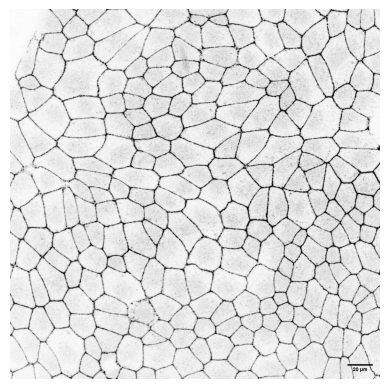

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive/")

import numpy as np
from skimage import io, filters, morphology, segmentation, color, measure
import matplotlib.pyplot as plt
import cv2
from skimage.measure import label, regionprops

thresh = 0.2 # to be optimized
imaddress = '/content/gdrive/MyDrive/work/epithelialSegmentationCovid/control/29.png'
# imaddress = '/content/gdrive/MyDrive/work/epithelialSegmentationCovid/plpro/32.png'
gray = cv2.imread(imaddress, cv2.IMREAD_GRAYSCALE).astype('float')

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()


def contour_properties(x_coords, y_coords): # this function is written by LLM
    # Ensure the contour is closed (first point == last point)
    if x_coords[0] != x_coords[-1] or y_coords[0] != y_coords[-1]:
        x = np.append(x_coords, x_coords[0])
        y = np.append(y_coords, y_coords[0])
    else:
        x = np.array(x_coords)
        y = np.array(y_coords)

    # Calculate area using Shoelace formula
    area = 0.5 * np.abs(np.sum(x[:-1] * y[1:] - x[1:] * y[:-1]))

    # Calculate perimeter
    dx = np.diff(x)
    dy = np.diff(y)
    perimeter = np.sum(np.sqrt(dx**2 + dy**2))

    return area, perimeter


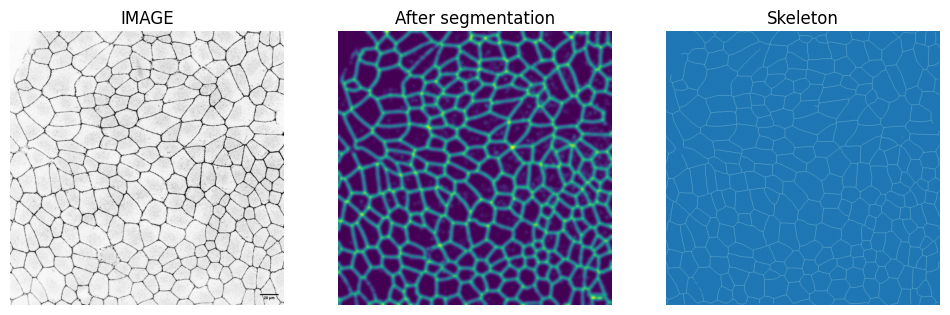

In [ ]:
thresh = 0.2 # to be optimize

# Find markers for watershed, compute gradient
gradient = filters.sobel(gray)

# Find markers (seeds)
markers = np.zeros_like(gray, dtype=np.int32)
markers[gradient < gradient.mean() * 0.5] = 1  # Background
markers[gradient > gradient.mean() * 1.5] = 2  # Foreground

# watersheding
labels = segmentation.watershed(gradient, markers)

# Removing small regions
labels = morphology.remove_small_objects(labels, min_size=50)
labels[labels == 1] = 0
labels[labels == 2] = 1

labels = filters.gaussian(labels, sigma=5, mode='reflect')

labels /= max(labels.flatten())

skeleton = 0*labels
skeleton[labels > thresh] = 1
skeleton[labels <= thresh] = 0

skeleton = morphology.skeletonize(skeleton)

# Show result
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('IMAGE')
axes[1].imshow(labels)
axes[1].set_title('After segmentation')
axes[2].imshow(skeleton, cmap='tab20')
axes[2].set_title('Skeleton')
for ax in axes:
    ax.axis('off')
plt.show()
#### SEGMENTATION DONE #####

#### PROCESSING NEXT #####

/tmp/ipython-input-1116908274.py:26: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  imtmp = morphology.remove_small_holes(imtmp, area_threshold=50)
/tmp/ipython-input-1116908274.py:57: UserWarning: Any labeled images will be returned as a boolean array. Did you mean to use a boolean array?
  imtmp = morphology.remove_small_holes(imtmp, area_threshold=50)


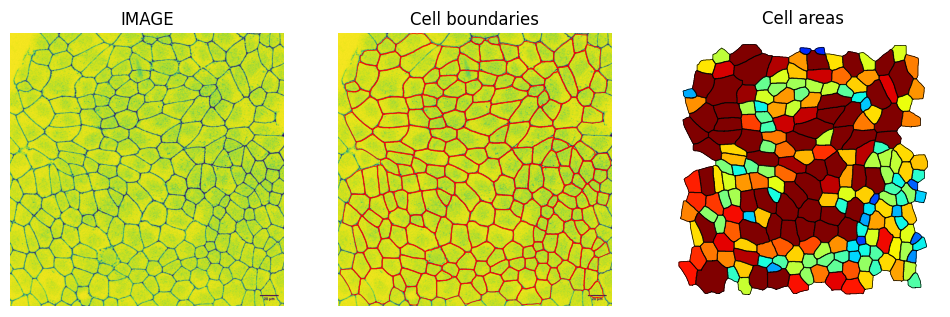

In [ ]:
labels = label(1 - skeleton, connectivity=1)
props = regionprops(labels)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(gray)
ax[1].imshow(gray)

areas = np.zeros(len(props))
perims = np.zeros(len(props))
m,n = np.shape(gray)
for i, prop in enumerate(props):
    # print(f"Component {i+1} (label={prop.label}):")
    # print(f"  Area: {prop.area}")
    # print(f"  Centroid: {prop.centroid}")
    # print(f"  Bounding box: {prop.bbox}")
    # print(f"  Perimeter: {prop.perimeter}")
    # print("-" * 40)

    # areas[i] = prop.area
    # perims[i] = prop.perimeter

    if i > 0:
        imtmp = 0*gray.astype(int)
        imtmp[labels==i] = 1
        imtmp = morphology.remove_small_holes(imtmp, area_threshold=50)

        contours = measure.find_contours(imtmp, level=0.9)
        for contour in contours:
            ys = contour[:, 0]
            xs = contour[:, 1]
            a,p = contour_properties(xs, ys)

            areas[i] = a
            perims[i] = p
            ### cell at the border, ignore
            if xs[0] == 0 or xs[-1] == 0 or xs[0] == n or xs[-1] == n:
                continue
            if ys[0] == 0 or ys[-1] == 0 or ys[0] == m or ys[-1] == m:
                continue
            ####

            ax[1].plot(xs,ys,'red',lw=0.5)

## plot the filled cells
import matplotlib.cm as cm
import matplotlib as mpl

cmap = mpl.colormaps.get_cmap('jet')
norm = mpl.colors.Normalize(vmin=100, vmax=5000)

#ax[2].imshow(gray)
for i, prop in enumerate(props):
    if i > 0:
        imtmp = 0*gray.astype(int)
        imtmp[labels==i] = 1
        imtmp = morphology.remove_small_holes(imtmp, area_threshold=50)

        contours = measure.find_contours(imtmp, level=0.9)
        for contour in contours:
            ys = contour[:, 0]
            xs = contour[:, 1]

            ### cell at the border, ignore
            if xs[0] == 0 or xs[-1] == 0 or xs[0] == n or xs[-1] == n:
                continue
            if ys[0] == 0 or ys[-1] == 0 or ys[0] == m or ys[-1] == m:
                continue
            ####

            cellColor = cmap(norm(areas[i]))
            ax[2].fill(xs,ys,color=cellColor,lw=0.5)
            ax[2].plot(xs,ys,'black',lw=0.5)

ax[0].set_title('IMAGE')
ax[1].set_title('Cell boundaries')
ax[2].set_title('Cell areas')

ax[2].invert_yaxis()
ax[2].set_aspect(1)

for axi in ax:
    axi.axis('off')
plt.show()

#### SAVE DATA TO CSV FILE ####
data2save = np.vstack((areas,perims)).T
np.savetxt(imaddress[:-4]+'_area_perimeter.csv', data2save, delimiter=',')